# Experiment 1A: ISI — Hidden-Layer Perturbation (Learnable Tau + Delay)

## Overview

This notebook implements Experiment 1A from the "Beyond Beyond Rate" project.
We train an SNN (with **learnable tau** AND **learnable axonal delays**) on
the ISI synthetic task with **no perturbation** (f=0), then evaluate by
applying spike-timing perturbation at the **output of the 1st hidden layer**
instead of the input.

**Key idea:** At test time we intercept the hidden layer's spike output,
replace a fraction *f* of spikes with randomly timed spikes (preserving spike
count per neuron), and measure how downstream accuracy degrades. This probes
whether the trained network's hidden representation relies on spike timing or
has collapsed to a rate code.

| Property | Value |
|---|---|
| Architecture | Input (10) → Hidden (100, SRMALPHA, learnable tau + delay) → Output (2) |
| Delays | Learnable axonal delays on both layers (max 15 time steps) |
| Training | f = 0 (unperturbed inputs) |
| Test-time perturbation | Hidden-layer output, f in {0, 0.2, 0.4, 0.6, 0.8, 1.0} |
| Dataset | ISI synthetic (`isi_dataset.h5`) |
| Framework | SLAYER (slayerPytorch) |

**Interpretation:**
- Accuracy degrades with increasing f → hidden layer preserves temporal structure.
- Accuracy stays flat → hidden layer collapsed temporal information into a rate code.
- Compare with `isi_tau.ipynb` to see whether learnable delays change the picture.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
import pickle
from typing import Optional

import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
#sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors. We use SRMALPHA neurons
with a **0.5 ms sampling period** (Ts=0.5, i.e. 2000 Hz sampling rate)
and 1000 ms (1 s) total sample duration (2000 time steps × 0.5 ms). The
delay variant adds learnable axonal delays (max 30 time steps = 15 ms)
on both layers, matching the 1000-rate baseline's 15 ms delay budget.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 0.5, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 301
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 48
MAX_DELAY = 30  # Maximum learnable delay in time steps (= 15 ms at Ts=0.5)

# --- Hidden-perturbation sweep ---
F_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
NUM_REPEATS = 3  # repeated evaluations per f to get error bars

## 3. Load ISI Dataset

Load the ISI spike-train dataset from the local HDF5 file.
Each sample has shape `(num_neurons, T)` with binary spike values.

In [3]:
def load_isi_data(data_file: str = "isi_dataset.h5"):
    """Load ISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]  # (N, num_neurons, T)
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_isi_data("isi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded isi_dataset.h5: X=(3598, 10, 2000), Y=(3598,)
Classes: [0 1], Time steps: 2000
Network config: 10 input neurons, 2 classes


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This destroys temporal
structure while preserving each neuron's spike count (i.e. the rate code).

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    SLAYER outputs 1/Ts per spike (e.g. 2.0 at Ts=0.5), so we detect spikes
    with a > 0.5 threshold and re-write relocated spikes with the same
    magnitude rather than hard-coding 1.

    Args:
        spike_train: Array of shape (num_neurons, T). Non-spike bins are 0;
            spike bins hold the SLAYER spike magnitude (1/Ts).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape and magnitude.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] > 0.5)[0]
        if len(spike_times) == 0:
            continue
        spike_value = float(spike_train[neuron_idx, spike_times[0]])

        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] < 0.5:
                new_train[neuron_idx, new_t] = spike_value
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly, and the original spike magnitude (SLAYER outputs
    1/Ts per spike, so 2.0 at Ts=0.5) is preserved on the relocated
    spikes. All operations stay on the input tensor's device, avoiding
    the CPU/numpy round-trip that dominates training cost when perturbation
    runs on every batch.

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5
    if not is_spike.any():
        return hidden_spikes

    # Detect SLAYER's spike magnitude (1/Ts) from the data itself.
    spike_value = x[is_spike].max().item()

    n_spikes = is_spike.sum(dim=-1, keepdim=True)            # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()       # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move                          # (B, C, T)
    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move

    # Re-emit spikes at the original SLAYER magnitude (not 0/1).
    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype) * spike_value
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple[float, float], total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and return train / val / test DataLoaders (no perturbation)."""
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx = get_split_indices(VAL_RANGE, len(X))
    test_idx = get_split_indices(TEST_RANGE, len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a **learnable PSP filter** AND
**learnable axonal delays** on both layers. This is the SGD-delay variant.

```
Input (10) → [delay1 + psp_filter + fc1 + spike] → Hidden (100)
                                                       ↓
                                ← perturbation applied here at test time
                                                       ↓
                              [delay2 + psp + fc2 + spike] → Output (2)
```

Two forward methods are provided:
- `forward`: standard pass used during training (no perturbation).
- `forward_with_hidden_perturbation`: intercepts hidden spikes,
  applies perturbation at level *f*, then continues to output.

In [6]:
class ISIDelayNetwork(nn.Module):
    """SLAYER SNN for ISI classification with learnable tau AND axonal delays.

    This is the SGD-delay variant. Delay modules are applied on both layers.
    Two forward paths:
    - ``forward``: standard pass (training).
    - ``forward_with_hidden_perturbation``: intercepts hidden spikes,
      applies perturbation, then continues to output (testing).
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
        max_delay: int = 30,
    ):
        super().__init__()
        self.max_delay = max_delay
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # filterLength=100 taps at Ts=0.5 ms covers 50 ms of history,
        # matching the 1000-rate baseline's 50-tap / 50 ms filter.
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=100, filterScale=1)
        self._initialize_alpha_filter()

        # Learnable axonal delays on both layers.
        # delay1 acts on the input side (before fc1+spike), delay2 sits at
        # the start of _second_layer (after the perturbation hook). This
        # keeps the hidden-layer output strictly binary.
        self.delay1 = slayer.delay(num_neurons)
        self.delay2 = slayer.delay(hidden_units)
        self._initialize_delays()

    # ------------------------------------------------------------------
    # Initialisation helpers
    # ------------------------------------------------------------------
    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]
        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))
        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def _initialize_delays(self) -> None:
        """Initialize delay parameters uniformly in [0, max_delay]."""
        with torch.no_grad():
            if hasattr(self.delay1, "delay"):
                self.delay1.delay.data.uniform_(0, self.max_delay)
            if hasattr(self.delay2, "delay"):
                self.delay2.delay.data.uniform_(0, self.max_delay)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Get current delay values as numpy arrays."""
        delays = {}
        if hasattr(self.delay1, "delay"):
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
        if hasattr(self.delay2, "delay"):
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

    # ------------------------------------------------------------------
    # Forward passes
    # ------------------------------------------------------------------
    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input → hidden spikes (delay1 + learnable PSP + fc1 + spike).

        Returns strictly binary spikes: ``slayer.spike`` is the last op.
        """
        x = self.delay1(x)
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes → output spikes (delay2 + standard PSP + fc2)."""
        x = self.delay2(hidden_spikes)
        return self.slayer.spike(self.fc2(self.slayer.psp(x)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass — no perturbation. Used during training."""
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)
        return self._second_layer(hidden_spikes)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with perturbation at the hidden-layer spike output.

        Performs the first layer normally, then disrupts the temporal
        structure of the hidden spike train before passing to layer 2.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate (0=none, 1=all).

        Returns:
            Output spike tensor after perturbed hidden representation.
        """
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)

        if f > 0:
            hidden_spikes = perturb_hidden_batch(hidden_spikes, f)

        return self._second_layer(hidden_spikes)

## 7. Training Loop

Train on **unperturbed** data (f=0). Standard SLAYER ProbSpikes loss with
the Nadam optimiser. Separate learning rates: regular weights at base LR,
PSP filter (tau) at LR×10 for faster temporal adaptation, delays at LR×5
for stable delay learning. The best checkpoint (by validation loss) is
restored at the end.

In [7]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    max_delay: int = 15,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
) -> tuple["ISIDelayNetwork", dict]:
    """Train the ISIDelayNetwork on unperturbed data.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        max_delay: Maximum learnable delay in time steps.
        epochs: Number of training epochs.
        lr: Base learning rate.
        seed: Random seed for reproducibility.

    Returns:
        Tuple of (trained network, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = ISIDelayNetwork(num_neurons, num_classes, hidden_units, max_delay).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    # Three parameter groups with different learning rates.
    regular_params, tau_params, delay_params = [], [], []
    for name, param in net.named_parameters():
        if "delay" in name:
            delay_params.append(param)
        elif "psp_filter" in name:
            tau_params.append(param)
        else:
            regular_params.append(param)

    param_groups = [{"params": regular_params, "lr": lr}]
    if tau_params:
        param_groups.append({"params": tau_params, "lr": lr * 10})
    if delay_params:
        param_groups.append({"params": delay_params, "lr": lr * 5})

    optimizer = snn.utils.optim.Nadam(param_groups)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5,
    )

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list[float] = []
    delay_history: list[dict] = []

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "delay_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validate ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()
                    outputs = net(x_batch)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            delays = net.get_delays()
            delay_history.append(delays)
            avg_delay = (
                np.mean([np.mean(d) for d in delays.values() if len(d) > 0])
                if delays else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)
            log["delay_mean"].append(float(avg_delay))

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
                delay=f"{avg_delay:.1f}",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    log["delay_history_mean"] = [
        float(np.mean([np.mean(d) for d in dh.values() if len(d) > 0])) if dh else 0.0
        for dh in delay_history
    ]
    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, the forward pass is intercepted at the hidden layer and
the spike output is perturbed before being fed to the second layer.

In [8]:
def test_with_hidden_perturbation(
    net: ISIDelayNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained ISIDelayNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to hidden spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    accuracy = correct / total
    return accuracy


def run_hidden_perturbation_sweep(
    net: ISIDelayNetwork,
    test_loader: DataLoader,
    f_values: list[float],
    num_repeats: int = 3,
) -> dict[float, dict]:
    """Sweep over perturbation levels and collect accuracy statistics.

    Each *f* is evaluated *num_repeats* times (different random seeds)
    to obtain mean and std.

    Args:
        net: Trained ISIDelayNetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per f.

    Returns:
        Dict mapping each f to {"mean", "std", "values"}.
    """
    results: dict[float, dict] = {}

    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        results[f] = {"mean": mean_acc, "std": std_acc, "values": accuracies}
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, tau evolution, and delay evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [9]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss, tau evolution, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss", markersize=2)
    axes[0].plot(log["epoch"], log["val_loss"], "s-", label="Val loss", markersize=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tau (ms)")
    axes[1].set_title("Learned Tau Over Training")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    axes[2].plot(log["delay_history_mean"])
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Mean Delay (time steps)")
    axes[2].set_title("Average Delay Over Training")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(results: dict[float, dict]) -> None:
    """Plot accuracy vs hidden perturbation level f."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.errorbar(f_vals, means, yerr=stds, fmt="o-", capsize=5, capthick=2,
                 color="tab:orange", label="SGD-delay (learnable tau + delay)")
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 1A — ISI: Accuracy vs Hidden-Layer Perturbation (Learnable Tau + Delay)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig("log/isi_delay_hidden_perturbation.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved to log/isi_delay_hidden_perturbation.png")

## 10. Run: Train the Model (f=0)

Train on unperturbed ISI data using the 301-epoch schedule. The best
checkpoint (lowest validation loss) is restored and saved to disk.

In [10]:
# Build DataLoaders — no perturbation at training time
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE,
)

# Train
net, training_log = train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_neurons=NUM_NEURONS,
    num_classes=NUM_CLASSES,
    hidden_units=HIDDEN_UNITS,
    max_delay=MAX_DELAY,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    seed=SEED,
)

# Sanity check: clean accuracy with no perturbation
clean_acc = test_with_hidden_perturbation(net, test_loader, f=0.0)
print(f"\nClean test accuracy (f=0, no perturbation): {clean_acc:.4f}")

# Save the trained model
os.makedirs("data", exist_ok=True)
model_path = "data/isi_delay_trained.pt"
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")

Split sizes — Train: 2158, Val: 540, Test: 540


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training: 100%|██████████| 20468/20468 [23:10<00:00, 14.72it/s, best=0.1125, delay=16.9, epoch=301, tau=33.0ms, val_loss=0.1993]



Clean test accuracy (f=0, no perturbation): 0.9796
Model saved to data/isi_delay_trained.pt


## 11. Plot Training Curves

Plot training/validation loss, tau evolution and delay evolution for the
trained model.

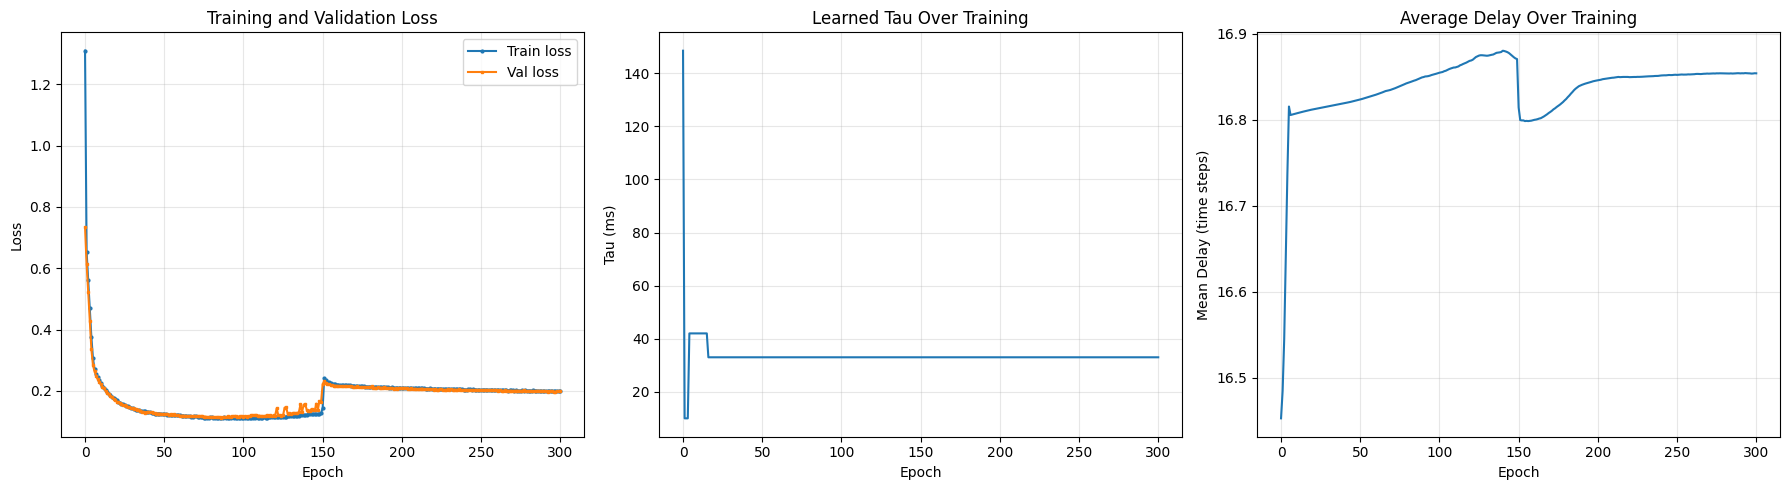

In [11]:
plot_training_curves(training_log)

## 12. Hidden-Perturbation Sweep

Apply perturbation at the hidden-layer output for f in {0, 0.2, 0.4, 0.6, 0.8, 1.0}.
Each level is repeated `NUM_REPEATS` times with different random seeds for error bars.

**What to look for:**
- **Steep degradation with f:** the hidden layer preserves spike-timing structure.
- **Flat curve near clean accuracy:** the hidden layer collapsed timing into a rate code.
- **Compare with `isi_tau.ipynb`:** if the delay model degrades more steeply
  than the tau-only model, learnable delays enable richer internal temporal coding.

In [12]:
print("=== Hidden-Layer Perturbation Sweep (ISI, learnable tau + delay) ===")
sweep_results = run_hidden_perturbation_sweep(
    net, test_loader,
    f_values=F_VALUES,
    num_repeats=NUM_REPEATS,
)

=== Hidden-Layer Perturbation Sweep (ISI, learnable tau + delay) ===
  f=0.0:  accuracy = 0.9796 +/- 0.0000
  f=0.1:  accuracy = 0.9790 +/- 0.0017
  f=0.2:  accuracy = 0.9685 +/- 0.0015
  f=0.3:  accuracy = 0.9549 +/- 0.0009
  f=0.4:  accuracy = 0.9451 +/- 0.0009
  f=0.5:  accuracy = 0.9222 +/- 0.0045
  f=0.6:  accuracy = 0.9142 +/- 0.0057
  f=0.7:  accuracy = 0.9006 +/- 0.0057
  f=0.8:  accuracy = 0.8840 +/- 0.0101
  f=0.9:  accuracy = 0.8852 +/- 0.0094
  f=1.0:  accuracy = 0.8728 +/- 0.0049


## 13. Plot Hidden-Perturbation Results

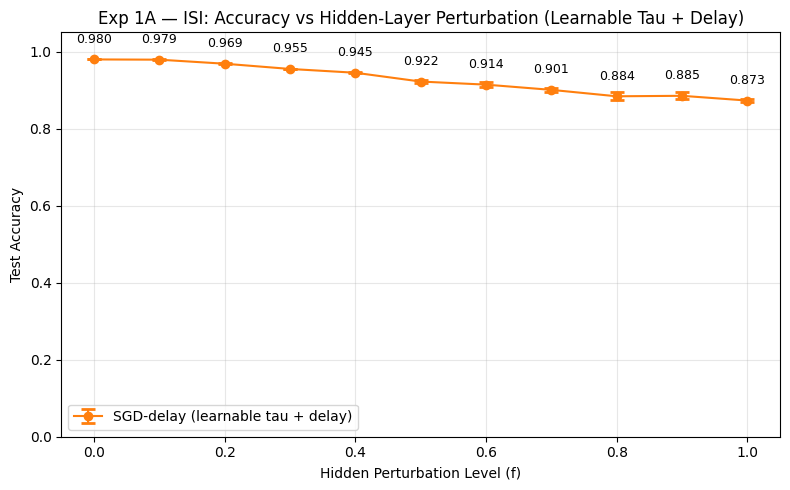

Figure saved to log/isi_delay_hidden_perturbation.png


In [13]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the perturbation sweep results and training log to JSON for later
comparison with `isi_tau.ipynb` (SGD tau-only model) and with the original
input-perturbation baseline from Beyond Rate.

In [14]:
# Save perturbation sweep results
results_serialisable = {
    str(f_val): {
        "mean": float(data["mean"]),
        "std": float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

os.makedirs("log", exist_ok=True)
results_path = "log/isi_delay_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# Save training log
training_log_serialisable = {
    k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
    for k, vals in training_log.items()
}
log_path = "log/isi_delay_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_log_serialisable, fp, indent=2)
print(f"Training log saved to {log_path}")

Perturbation results saved to log/isi_delay_hidden_perturbation_results.json
Training log saved to log/isi_delay_training_log.json


## 15. Model Analysis

Inspect the learned tau, delay distributions, PSP filter shape, and
per-layer weight statistics.

=== Learned Parameter Analysis (ISI, learnable tau + delay) ===
Learned effective tau: 33.00 ms
PSP filter — max: 0.9760, mean: -0.5645, length: 100 taps
Learned delay1: mean=18.57, std=6.82, min=8.57, max=29.01
Learned delay2: mean=15.13, std=8.53, min=0.11, max=31.21


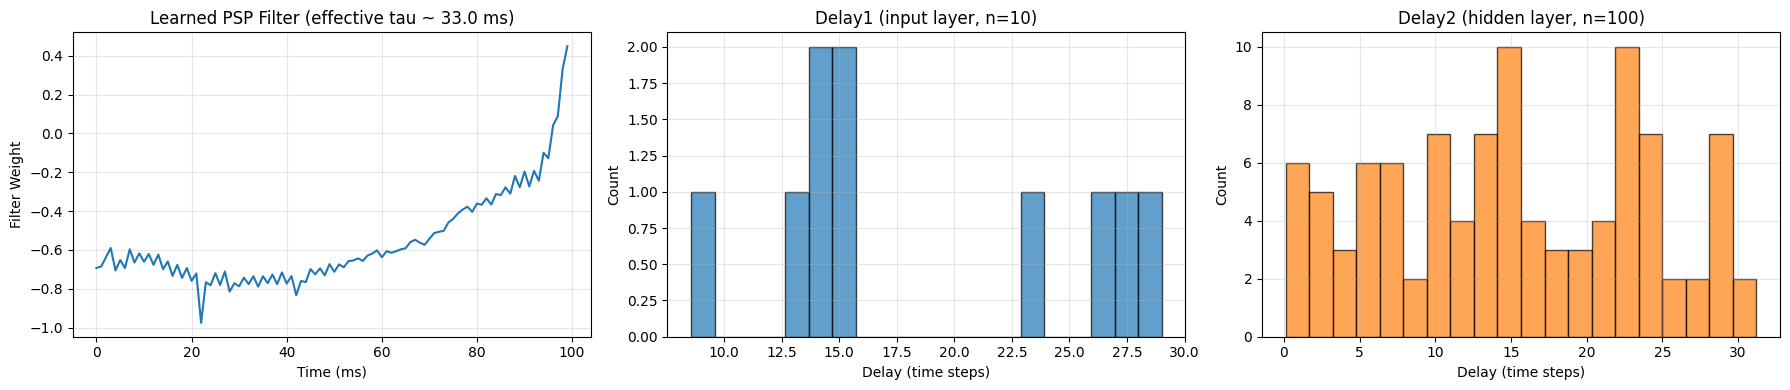


Weight statistics:
  fc1.weight_g: mean=5.6735, std=0.7374, shape=[100, 1, 1, 1, 1]
  fc1.weight_v: mean=0.0333, std=1.8074, shape=[100, 10, 1, 1, 1]
  fc2.weight_g: mean=7.8352, std=2.8044, shape=[2, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.1275, std=0.5853, shape=[2, 100, 1, 1, 1]
  psp_filter.weight: mean=-0.5645, std=0.2430, shape=[1, 1, 1, 1, 100]


In [15]:
print("=== Learned Parameter Analysis (ISI, learnable tau + delay) ===")

tau_val = net.get_tau().item() / MS
print(f"Learned effective tau: {tau_val:.2f} ms")

filter_weights = net.psp_filter.weight.data.squeeze().cpu().numpy()
print(
    f"PSP filter — max: {np.max(np.abs(filter_weights)):.4f}, "
    f"mean: {np.mean(filter_weights):.4f}, "
    f"length: {len(filter_weights)} taps"
)

# Delay statistics
delays = net.get_delays()
for delay_name, delay_values in delays.items():
    if len(delay_values) > 0:
        print(
            f"Learned {delay_name}: "
            f"mean={np.mean(delay_values):.2f}, "
            f"std={np.std(delay_values):.2f}, "
            f"min={np.min(delay_values):.2f}, "
            f"max={np.max(delay_values):.2f}"
        )

# Plot the learned PSP filter and delay distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.flip(filter_weights))
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Filter Weight")
axes[0].set_title(f"Learned PSP Filter (effective tau ~ {tau_val:.1f} ms)")
axes[0].grid(True, alpha=0.3)

if "delay1" in delays and len(delays["delay1"]) > 0:
    axes[1].hist(
        delays["delay1"].flatten(), bins=20,
        color="tab:blue", alpha=0.7, edgecolor="black",
    )
    axes[1].set_xlabel("Delay (time steps)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Delay1 (input layer, n={delays['delay1'].size})")
    axes[1].grid(True, alpha=0.3)

if "delay2" in delays and len(delays["delay2"]) > 0:
    axes[2].hist(
        delays["delay2"].flatten(), bins=20,
        color="tab:orange", alpha=0.7, edgecolor="black",
    )
    axes[2].set_xlabel("Delay (time steps)")
    axes[2].set_ylabel("Count")
    axes[2].set_title(f"Delay2 (hidden layer, n={delays['delay2'].size})")
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-layer weight statistics
print("\nWeight statistics:")
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )